In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn import metrics
from xgboost import XGBRegressor

In [4]:
mart_data = pd.read_csv(r'C:\Users\HP\OneDrive\Desktop\python\pyCourse\csvFiles\Test.csv')

In [5]:
mart_data.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type
0,FDW58,20.750,Low Fat,0.007565,Snack Foods,107.8622,OUT049,1999,Medium,Tier 1,Supermarket Type1
1,FDW14,8.300,reg,0.038428,Dairy,87.3198,OUT017,2007,NaN,Tier 2,Supermarket Type1
2,NCN55,14.600,Low Fat,0.099575,Others,241.7538,OUT010,1998,NaN,Tier 3,Grocery Store
3,FDQ58,7.315,Low Fat,0.015388,Snack Foods,155.0340,OUT017,2007,NaN,Tier 2,Supermarket Type1
4,FDY38,NaN,Regular,0.118599,Dairy,234.2300,OUT027,1985,Medium,Tier 3,Supermarket Type3


In [6]:
mart_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5681 entries, 0 to 5680
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            5681 non-null   object 
 1   Item_Weight                4705 non-null   float64
 2   Item_Fat_Content           5681 non-null   object 
 3   Item_Visibility            5681 non-null   float64
 4   Item_Type                  5681 non-null   object 
 5   Item_MRP                   5681 non-null   float64
 6   Outlet_Identifier          5681 non-null   object 
 7   Outlet_Establishment_Year  5681 non-null   int64  
 8   Outlet_Size                4075 non-null   object 
 9   Outlet_Location_Type       5681 non-null   object 
 10  Outlet_Type                5681 non-null   object 
dtypes: float64(3), int64(1), object(7)
memory usage: 488.3+ KB


Catagorical features: textual values
- Item_Identifier
- Item_Fat_Content	
- Item_Type	Item_MRP
- Outlet_Identifier	
- Outlet_Size
- Outlet_Location_Type
- Outlet_Type



In [7]:
# checing missing val
mart_data.isnull().sum()

Item_Identifier                 0
Item_Weight                   976
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                  1606
Outlet_Location_Type            0
Outlet_Type                     0
dtype: int64

Handling Missing Values

In [8]:
mart_data['Item_Weight'].isnull().sum()

np.int64(976)

C:\Users\HP\AppData\Local\Temp\ipykernel_10792\242735425.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(mart_data.Item_Weight)


<Axes: xlabel='Item_Weight', ylabel='Density'>

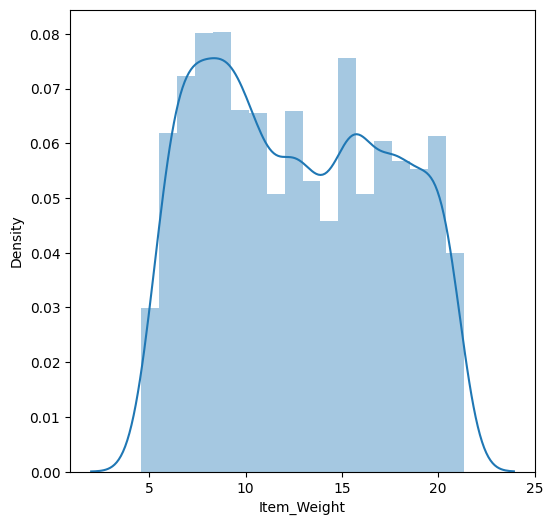

In [9]:
fig, ax = plt.subplots(figsize=(6,6))
sns.distplot(mart_data.Item_Weight)

# Handling the missing val 

In [10]:
mart_data['Item_Weight'].fillna(mart_data['Item_Weight'].mean(), inplace=True)

In [11]:
mart_data.isnull().sum()

Item_Identifier                 0
Item_Weight                     0
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                  1606
Outlet_Location_Type            0
Outlet_Type                     0
dtype: int64

Replacing the missing val in outlet_size with mode

In [12]:
mode_of_outlet_size = mart_data.pivot_table(values='Outlet_Size', columns='Outlet_Type', aggfunc=(lambda x: x.mode()[0]))

- Lambda --> we use when we need to write one line fn and don't need again & again just like we make fn using def keyword for using it several time

In [13]:
print(mode_of_outlet_size)

Outlet_Type Grocery Store Supermarket Type1 Supermarket Type2  \
Outlet_Size         Small             Small            Medium   

Outlet_Type Supermarket Type3  
Outlet_Size            Medium  


In [14]:
missing_val = mart_data['Outlet_Size'].isnull()

In [15]:
print(missing_val)

0       False
1        True
2        True
3        True
4       False
        ...  
5676    False
5677    False
5678     True
5679     True
5680     True
Name: Outlet_Size, Length: 5681, dtype: bool


In [16]:
mart_data.loc[missing_val, 'Outlet_Size'] = mart_data.loc[missing_val, 'Outlet_Size'].apply(lambda x : mode_of_outlet_size)

In [17]:
mart_data.isnull().sum()

Item_Identifier              0
Item_Weight                  0
Item_Fat_Content             0
Item_Visibility              0
Item_Type                    0
Item_MRP                     0
Outlet_Identifier            0
Outlet_Establishment_Year    0
Outlet_Size                  0
Outlet_Location_Type         0
Outlet_Type                  0
dtype: int64

# Data Analysis

In [18]:
mart_data.describe()

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year
count,5681.000000,5681.000000,5681.000000,5681.000000
mean,12.695633,0.065684,141.023273,1997.828903
std,4.245189,0.051252,61.809091,8.372256
min,4.555000,0.000000,31.990000,1985.000000
25%,9.195000,0.027047,94.412000,1987.000000
50%,12.695633,0.054154,141.415400,1999.000000
75%,15.850000,0.093463,186.026600,2004.000000
max,21.350000,0.323637,266.588400,2009.000000


In [19]:
sns.set()

C:\Users\HP\AppData\Local\Temp\ipykernel_10792\2671208454.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(mart_data['Item_Weight'])


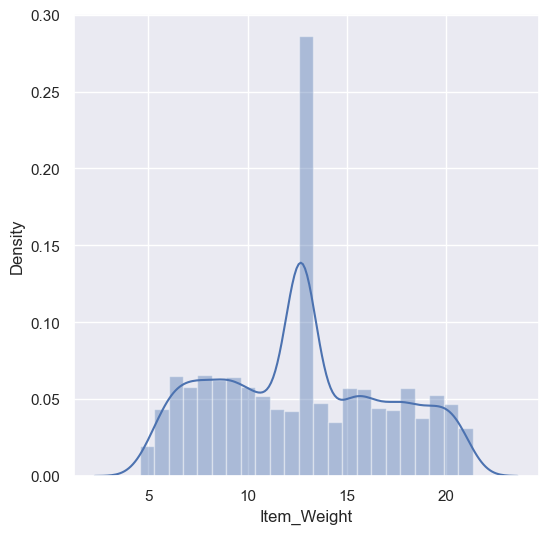

In [20]:
plt.figure(figsize=(6,6))
sns.distplot(mart_data['Item_Weight'])
plt.show()

C:\Users\HP\AppData\Local\Temp\ipykernel_10792\598509403.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(mart_data['Item_Visibility'])


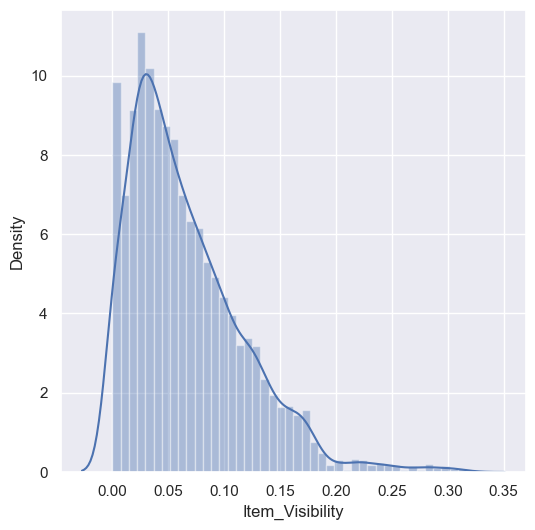

In [21]:
plt.figure(figsize=(6,6))
sns.distplot(mart_data['Item_Visibility'])
plt.show()

C:\Users\HP\AppData\Local\Temp\ipykernel_10792\108818578.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(mart_data['Item_MRP'])


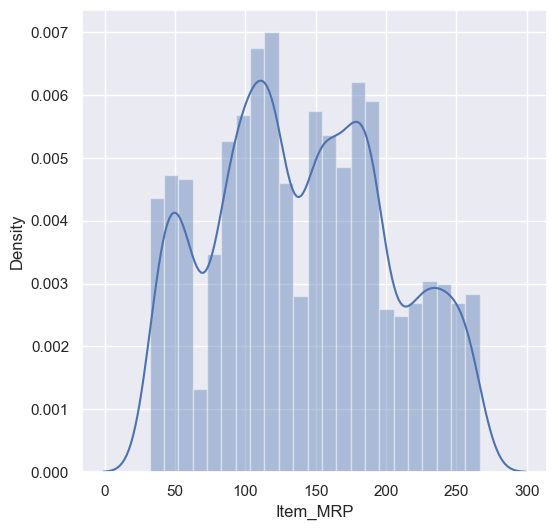

In [22]:
plt.figure(figsize=(6,6))
sns.distplot(mart_data['Item_MRP'])
plt.show()

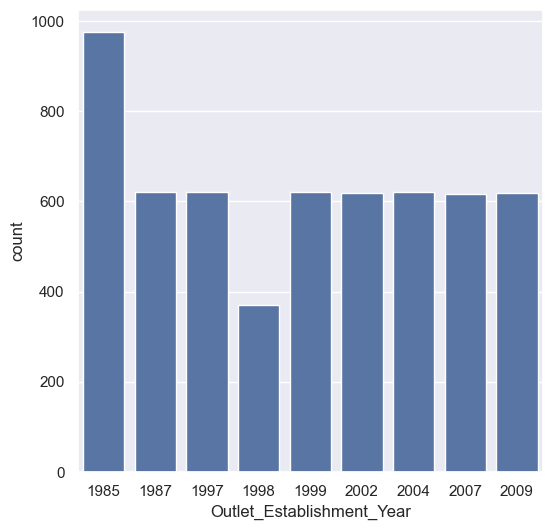

In [23]:
plt.figure(figsize=(6,6))
sns.countplot(x = 'Outlet_Establishment_Year', data=mart_data)
plt.show()

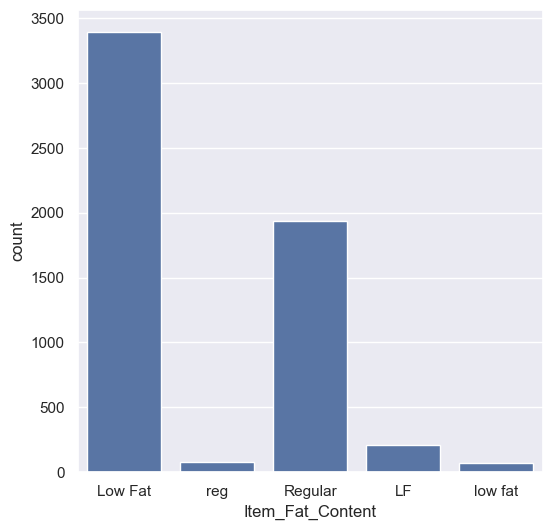

In [24]:
plt.figure(figsize=(6,6))
sns.countplot(x = 'Item_Fat_Content', data=mart_data)
plt.show()

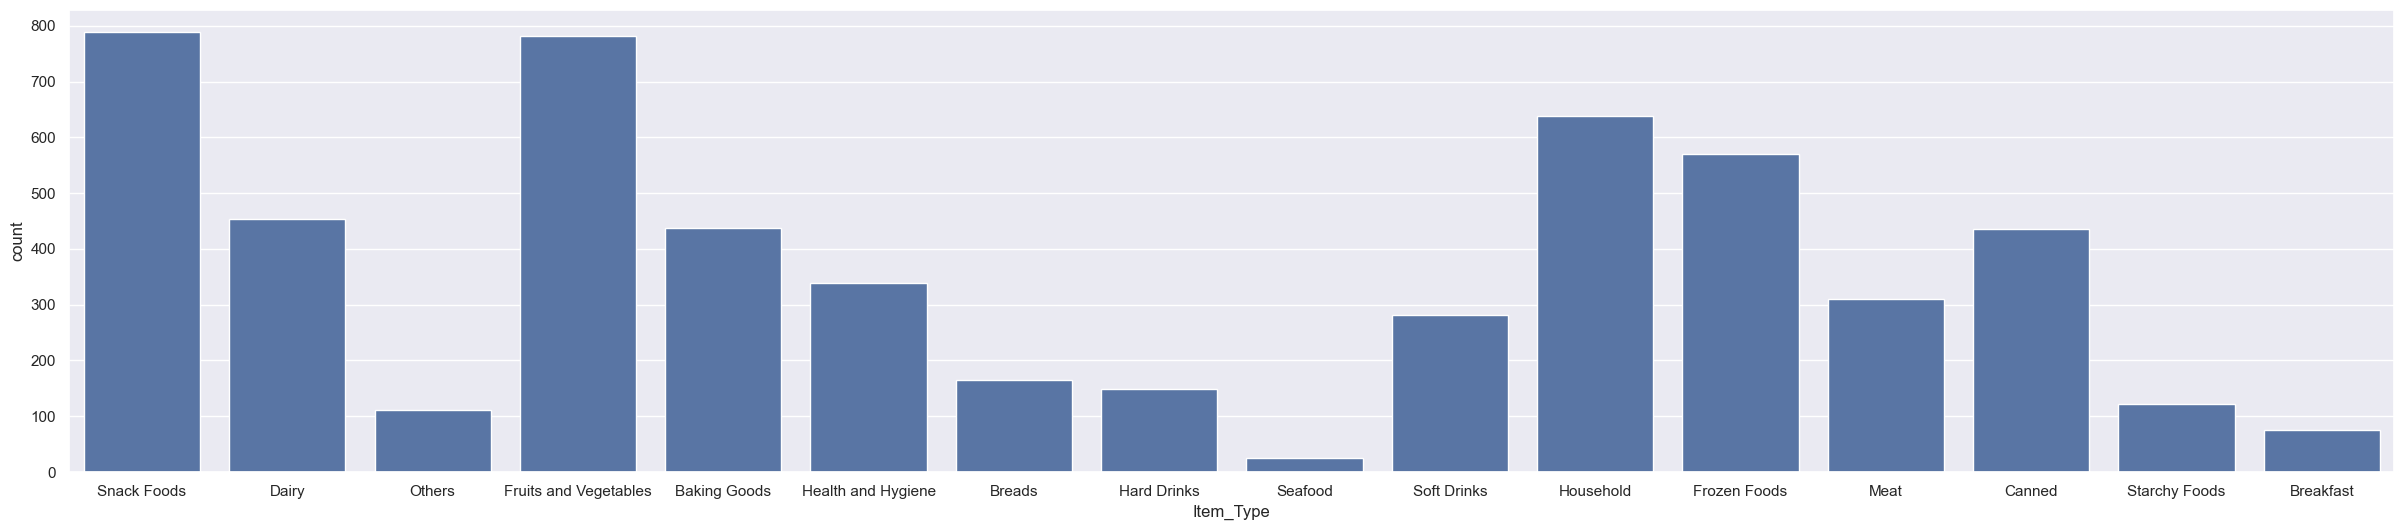

In [25]:
plt.figure(figsize=(30,6))
sns.countplot(x = 'Item_Type', data=mart_data)
plt.show()

# Data Pre-Processing

In [26]:
mart_data.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type
0,FDW58,20.750000,Low Fat,0.007565,Snack Foods,107.8622,OUT049,1999,Medium,Tier 1,Supermarket Type1
1,FDW14,8.300000,reg,0.038428,Dairy,87.3198,OUT017,2007,Outlet_Type Grocery Store Supermarket Type1 Su...,Tier 2,Supermarket Type1
2,NCN55,14.600000,Low Fat,0.099575,Others,241.7538,OUT010,1998,Outlet_Type Grocery Store Supermarket Type1 Su...,Tier 3,Grocery Store
3,FDQ58,7.315000,Low Fat,0.015388,Snack Foods,155.0340,OUT017,2007,Outlet_Type Grocery Store Supermarket Type1 Su...,Tier 2,Supermarket Type1
4,FDY38,12.695633,Regular,0.118599,Dairy,234.2300,OUT027,1985,Medium,Tier 3,Supermarket Type3


In [27]:
# combining fat content labels same values
mart_data['Item_Fat_Content'].value_counts()

Item_Fat_Content
Low Fat    3396
Regular    1935
LF          206
reg          78
low fat      66
Name: count, dtype: int64

As previously not done

In [28]:
mart_data.replace({'Item_Fat_Content': {'low fat':'Low Fat', 'LF':'Low Fat', 'reg':'Regular'}}, inplace=True)

In [29]:
mart_data['Item_Fat_Content'].value_counts()

Item_Fat_Content
Low Fat    3668
Regular    2013
Name: count, dtype: int64

- Converting all catagorical values into numerical values.
- So we use label encoding

# Label Encoding

In [30]:
encoder = LabelEncoder()

- Encoding all catastrophic value label

In [31]:
lab_encoder = encoder.fit_transform(mart_data.Item_Identifier)
lab_encoder1 = encoder.fit_transform(mart_data.Item_Fat_Content)
lab_encoder2 = encoder.fit_transform(mart_data.Item_Type)
lab_encoder3 = encoder.fit_transform(mart_data.Outlet_Identifier)
lab_encoder4 = encoder.fit_transform(mart_data.Outlet_Location_Type)
lab_encoder5 = encoder.fit_transform(mart_data.Outlet_Type)

In [32]:
mart_data['Item_Identifier1'] = lab_encoder
mart_data['Item_Fat_Content1'] = lab_encoder1
mart_data['Item_Type1'] = lab_encoder2
mart_data['Outlet_Identifier1'] = lab_encoder3
mart_data['Outlet_Location_Type1'] = lab_encoder4
mart_data['Outlet_Type1'] = lab_encoder5

In [33]:
mart_data.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Identifier1,Item_Fat_Content1,Item_Type1,Outlet_Identifier1,Outlet_Location_Type1,Outlet_Type1
0,FDW58,20.750000,Low Fat,0.007565,Snack Foods,107.8622,OUT049,1999,Medium,Tier 1,Supermarket Type1,1103,0,13,9,0,1
1,FDW14,8.300000,Regular,0.038428,Dairy,87.3198,OUT017,2007,Outlet_Type Grocery Store Supermarket Type1 Su...,Tier 2,Supermarket Type1,1067,1,4,2,1,1
2,NCN55,14.600000,Low Fat,0.099575,Others,241.7538,OUT010,1998,Outlet_Type Grocery Store Supermarket Type1 Su...,Tier 3,Grocery Store,1406,0,11,0,2,0
3,FDQ58,7.315000,Low Fat,0.015388,Snack Foods,155.0340,OUT017,2007,Outlet_Type Grocery Store Supermarket Type1 Su...,Tier 2,Supermarket Type1,809,0,13,2,1,1
4,FDY38,12.695633,Regular,0.118599,Dairy,234.2300,OUT027,1985,Medium,Tier 3,Supermarket Type3,1184,1,4,5,2,3


- Now encodeing the rest of catastrophic labels

# Splitting features and target

In [43]:
# features is here
x = mart_data.drop(columns='Item_Visibility', axis=1)
y = mart_data['Item_Visibility']

In [2]:
# Splitting training & testing data
# x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=2)

- training & testing data
- training model
- evaluation
- r^2 val  --> lies b/w 0 to 1 and used to evaluate performance of model
- It sees how close model predicted the val to original val

- regressor = XGBRegressor
- regressor.fit(x_train, y_train)
- training_pred = regressor.predict(x_train)
- r2_train = metrices.r2_score(y_train, training_pred)